# Lab: Visualizing Text Data

Online reviews contain information that cannot be summarized directly until we decide what evidence to extract from the text. In this lab, you will compare historical high- and low-rated visitor reviews of Universal Studios Florida.

Ratings tell us whether visitors evaluated their experiences favorably. The review text can help us investigate what visitors chose to discuss, while review length gives us a simple quantitative feature calculated from text.

## Learning goals

By the end of this lab, you should be able to:

- prepare review text for analysis;
- convert text into word-frequency and review-length features;
- create and interpret word clouds, frequency bar charts, and a box plot;
- compare text-derived evidence across groups; and
- explain important limits of review and word-frequency data.

## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response. Do not submit an AI response that you cannot explain.

## Dataset

The dataset is a fixed random sample of 3,000 English-language reviews of Universal Studios Florida. It was prepared from the CC0 [*Reviews of Universal Studios* dataset published on Kaggle](https://www.kaggle.com/datasets/dwiknrd/reviewuniversalstudio). The source contains more than 50,000 reviews of the Florida, Japan, and Singapore parks that were posted on Tripadvisor. For this dataset, the Florida reviews were selected, text encoding was repaired where possible, duplicate and blank reviews were removed, reviewer names were omitted, and a fixed random sample was drawn while retaining the source rating distribution.

The dataset contains four features and no missing values. Its reviews extend from February 2004 through May 2021, so they describe historical visitor experiences rather than current park conditions. The sample retains the unequal rating distribution found in the source data: a much larger number of reviews have ratings of four or five stars than ratings of one or two stars. It should not be treated as a representative sample of all visitors.

# Step 1: Question

> **How did high- and low-rated Universal Studios Florida reviews differ in their commonly used words and review lengths?**

For this analysis:

- **Low-rated reviews** have ratings of one or two stars.
- **High-rated reviews** have ratings of four or five stars.
- Three-star reviews are treated as neutral and are not included in the comparison.

**What topics or words do you predict will be especially common in low-rated reviews?**

Your answer: I predict that low-rated reviews will commonly mention long wait times, crowds, expensive prices, bad service, and problems with rides.

**Do you predict that low- or high-rated reviews will generally be longer?**

Your answer: I predict that low-rated reviews will generally be longer because visitors may give more details when explaining a negative experience.

# Step 2: Data

## Install WordCloud if needed

`wordcloud` is not included automatically in every Python environment. If you have not installed it in the current environment, run the next cell before importing the libraries. You normally need to install it only once for an environment.

If it is already installed, the command will confirm that the requirement is satisfied.

In [15]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 1. Import the libraries

The specialized imports for regular expressions, word counts, stopwords, and word clouds are provided. Complete the following code cell by importing Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.

In [16]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

# Import Pandas, Matplotlib's pyplot, and Seaborn below.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Read the data

Read `data/universal_orlando_reviews_sample.csv` into a DataFrame named `reviews`. Use `parse_dates=["review_date"]`.

In [17]:
# Write your code here.
reviews = pd.read_csv(
    "data/universal_orlando_reviews_sample.csv",
    parse_dates=["review_date"]
)

reviews

,review_id,rating,review_text,review_date
0,1,5.0,"If you visit Orlando, you have to take two day...",2004-02-17
1,2,5.0,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...",2004-07-06
2,3,1.0,Went to universal this september. What a waste...,2004-10-25
3,4,5.0,I think these parks (Universal Studios and Isl...,2005-01-03
4,5,1.0,"3 hours to get on a ride, $5 icees and $7 for ...",2005-03-31
...,...,...,...,...
2995,2996,1.0,TLDR; They don’t observe or enforce Covid safe...,2021-04-28
2996,2997,1.0,I've been waiting multiple DAYS on the phone t...,2021-05-04
2997,2998,1.0,✅ $850💵 + ⏰ hours of high heat 91 degrees🔥 & 😷...,2021-05-04
2998,2999,3.0,My husband and I visited Universal a couple ye...,2021-05-06


## 3. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.

In [18]:
# Write your code here.
display(reviews.head())
display(reviews.tail())

reviews.info()

reviews.isnull().sum()

,review_id,rating,review_text,review_date
0,1,5.0,"If you visit Orlando, you have to take two day...",2004-02-17
1,2,5.0,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...",2004-07-06
2,3,1.0,Went to universal this september. What a waste...,2004-10-25
3,4,5.0,I think these parks (Universal Studios and Isl...,2005-01-03
4,5,1.0,"3 hours to get on a ride, $5 icees and $7 for ...",2005-03-31


,review_id,rating,review_text,review_date
2995,2996,1.0,TLDR; They don’t observe or enforce Covid safe...,2021-04-28
2996,2997,1.0,I've been waiting multiple DAYS on the phone t...,2021-05-04
2997,2998,1.0,✅ $850💵 + ⏰ hours of high heat 91 degrees🔥 & 😷...,2021-05-04
2998,2999,3.0,My husband and I visited Universal a couple ye...,2021-05-06
2999,3000,5.0,Harry Potter world was especially awesome and ...,2021-05-15


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    3000 non-null   int64         
 1   rating       3000 non-null   float64       
 2   review_text  3000 non-null   object        
 3   review_date  3000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 93.9+ KB


review_id      0
rating         0
review_text    0
review_date    0
dtype: int64

### Data dictionary

| Feature | Meaning |
| --- | --- |
| `review_id` | Course-dataset identifier for a review |
| `rating` | Visitor rating from one to five stars |
| `review_text` | Written visitor review |
| `review_date` | Calendar date associated with the review |

Complete the table using the data dictionary, `.info()`, and `.isnull().sum()`.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `review_id` | Identifier | `int64` | 0 |
| `rating` | Quantitative | `float64` | 0 |
| `review_text` | Text | `object` | 0 |
| `review_date` | Date/Time | `datetime64[ns]` | 0 |

**What does one row represent?**

Your answer: One row represents one visitor review of Universal Studios Florida.

**What population can this dataset help us understand?**

Your answer: This dataset can help us understand visitors who posted reviews about Universal Studios Florida on Tripadvisor between 2004 and 2021.

# Step 3: Operation

## 4. Create rating groups

Use `pd.cut()` to create `rating_group` from `rating` with:

- `bins=[0, 2, 3, 5]`; and
- `labels=["Low (1–2)", "Neutral (3)", "High (4–5)"]`.

Then display the frequency of each group in rating order. The intervals created by these bins place ratings greater than 0 through 2 in Low, greater than 2 through 3 in Neutral, and greater than 3 through 5 in High.

In [19]:
# Write your code here.
reviews["rating_group"] = pd.cut(
    reviews["rating"],
    bins=[0, 2, 3, 5],
    labels=["Low (1–2)", "Neutral (3)", "High (4–5)"]
)

reviews["rating_group"].value_counts(sort=False)

rating_group
Low (1–2)       273
Neutral (3)     278
High (4–5)     2449
Name: count, dtype: int64

## 5. Select the comparison groups

Create `comparison` containing reviews whose `rating_group` is not `Neutral (3)`. Use `.copy()` because you will add calculated features to this new DataFrame.

In [20]:
# Write your code here.
comparison = reviews[
    reviews["rating_group"] != "Neutral (3)"
].copy()

comparison["rating_group"].value_counts(sort=False)

rating_group
Low (1–2)       273
Neutral (3)       0
High (4–5)     2449
Name: count, dtype: int64

**Why are three-star reviews excluded from this particular comparison?**

Your answer: Three-star reviews are excluded because they are considered neutral, and this comparison focuses on the differences between low- and high-rated reviews.

## 6. Calculate review length

Create `review_length_words` by applying `.str.split()` to `review_text` and then using `.str.len()` to count the resulting words in each review.

The first `.str` gives access to string methods for every value in the Series. After splitting, each row contains a list of words; the second `.str.len()` counts the items in each list.

In [21]:
# Write your code here.
comparison["review_length_words"] = (
    comparison["review_text"].str.split().str.len()
)

comparison[["review_text", "review_length_words"]].head()

,review_text,review_length_words
0,"If you visit Orlando, you have to take two day...",37
1,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...",330
2,Went to universal this september. What a waste...,96
3,I think these parks (Universal Studios and Isl...,1307
4,"3 hours to get on a ride, $5 icees and $7 for ...",26


## 7. Prepare the words

Run the provided code below. The `tokenize()` function:

1. converts text to lowercase;
2. uses the regular expression `[a-z']+` to find sequences of letters and apostrophes;
3. removes short words and common English stopwords; and
4. removes `park`, `parks`, `universal`, `orlando`, `studio`, `studios`, `just`, `like`, `went`, and `got` because they are generic or describe nearly every review and would distract from more informative terms.

We intentionally retain `ride` and `rides`. What visitors say about rides may help distinguish positive and negative experiences.

The function returns a list of cleaned words called **tokens**. `.map(tokenize)` applies the function to each review. `.str.join(" ")` joins each review's tokens into cleaned text for the word clouds.

In [22]:
additional_stopwords = {
    "park", "parks", "universal", "orlando", "studio", "studios",
    "just", "like", "went", "got"
}
stop_words = set(ENGLISH_STOP_WORDS) | additional_stopwords


def tokenize(text):
    words = re.findall(r"[a-z']+", text.lower())
    return [
        word
        for word in words
        if len(word) > 2 and word not in stop_words
    ]


comparison["tokens"] = comparison["review_text"].map(tokenize)
comparison["clean_text"] = comparison["tokens"].str.join(" ")

# Step 4: Check

## 8. Check the calculated features

Display:

- the number of reviews in each comparison group;
- missing-value counts for `rating_group`, `review_length_words`, `tokens`, and `clean_text`;
- `.describe()` for review length grouped by rating group; and
- the original text, tokens, and cleaned text for the first two comparison records.

In [23]:
# Write your code here.
# Number of reviews in each comparison group
display(comparison["rating_group"].value_counts(sort=False))

# Missing values in calculated features
display(
    comparison[
        ["rating_group", "review_length_words", "tokens", "clean_text"]
    ].isnull().sum()
)

# Review length statistics by rating group
display(
    comparison.groupby(
        "rating_group",
        observed=True
    )["review_length_words"].describe()
)

# First two comparison records
display(
    comparison[
        ["review_text", "tokens", "clean_text"]
    ].head(2)
)

rating_group
Low (1–2)       273
Neutral (3)       0
High (4–5)     2449
Name: count, dtype: int64

rating_group           0
review_length_words    0
tokens                 0
clean_text             0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
rating_group,,,,,,,,
Low (1–2),273.0,196.483516,226.205172,15.0,74.0,134.0,235.0,2253.0
High (4–5),2449.0,112.192323,132.441152,8.0,40.0,69.0,133.0,2243.0


,review_text,tokens,clean_text
0,"If you visit Orlando, you have to take two day...","[visit, days, fun, best, rides, spider, man, i...",visit days fun best rides spider man islands a...
1,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...","[family, adults, kids, visited, islands, adven...",family adults kids visited islands adventure r...


**What evidence confirms that the two comparison groups are substantially different in size?**

Your answer: The High group has 2,449 reviews, while the Low group has only 273, showing a large difference in group size.

**Why must group size be considered when comparing raw word frequencies?**

Your answer: A larger group has more reviews and therefore more chances for words to appear, so raw frequencies can be higher simply because the group is larger.

# Step 5: Evidence

## 9. Create word clouds

Run the provided code to create one word cloud for each rating group. The code joins each group's `clean_text` values into one string and generates a word cloud with a white background. `plt.axis("off")` hides axes that do not represent meaningful quantities in a word cloud.

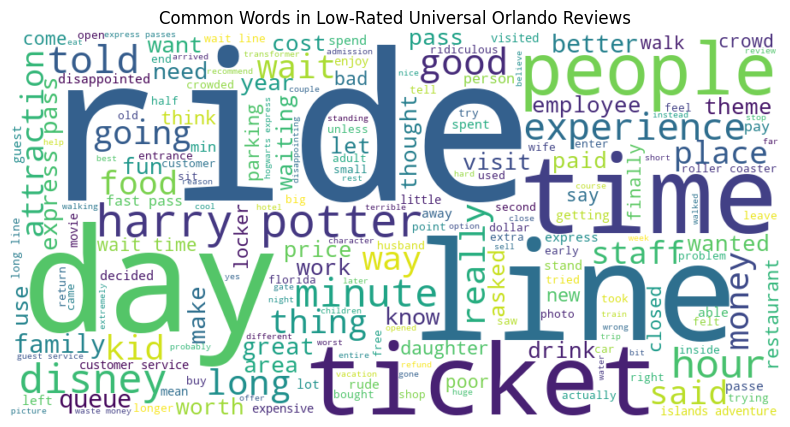

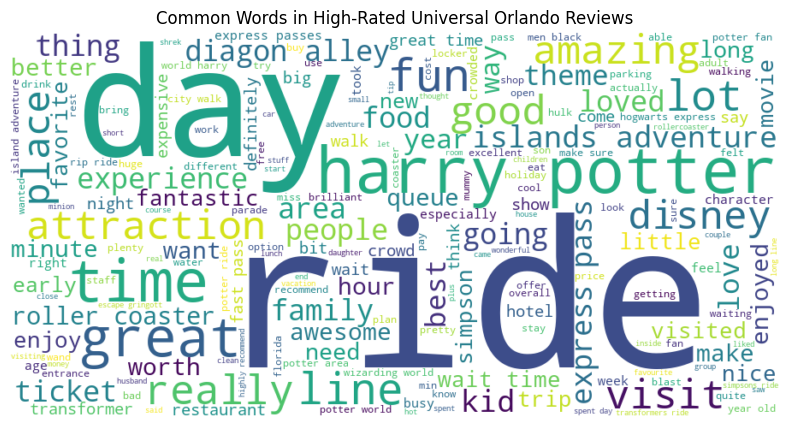

In [24]:
low_text = " ".join(
    comparison.loc[
        comparison["rating_group"] == "Low (1–2)",
        "clean_text"
    ]
)
high_text = " ".join(
    comparison.loc[
        comparison["rating_group"] == "High (4–5)",
        "clean_text"
    ]
)

low_cloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(low_text)

plt.figure(figsize=(10, 5))
plt.imshow(low_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Low-Rated Universal Orlando Reviews")
plt.show()

high_cloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(high_text)

plt.figure(figsize=(10, 5))
plt.imshow(high_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in High-Rated Universal Orlando Reviews")
plt.show()

**What is one apparent difference between the two word clouds?**

Your answer: Low-rated reviews focus more on words like "time" and "ticket," while high-rated reviews show more positive words like "great" and "fun."

**What is one limitation of using word clouds for this comparison?**

Your answer: Word clouds show which words are common, but they do not show the context in which the words were used.

**After viewing the word clouds, recommend one additional stopword that could make the comparison more informative. Explain your choice.**

Your answer: I would add "harry" as a stopword because it appears prominently in both groups and does not help much in distinguishing between low- and high-rated reviews.

## 10. Create word-frequency bar charts

Run the provided code. `frequency_frame()` counts every token in a selected rating group, keeps the 15 most frequent words, and sorts them from most to least frequent. With a horizontal Seaborn bar chart, this ordering places the most frequent word at the top.

The code creates separate figures for the Low and High rating groups. The tables are used to construct the figures but are not printed.

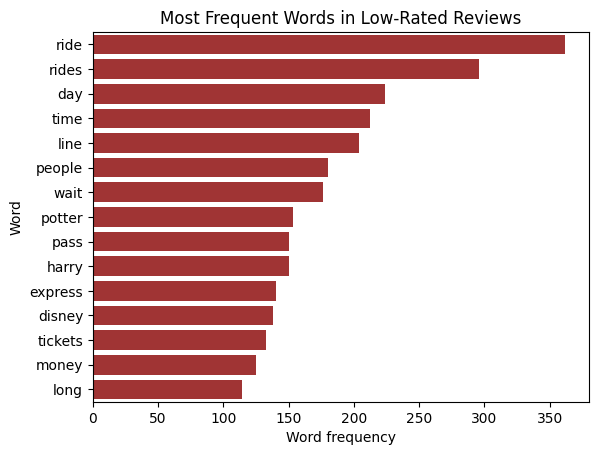

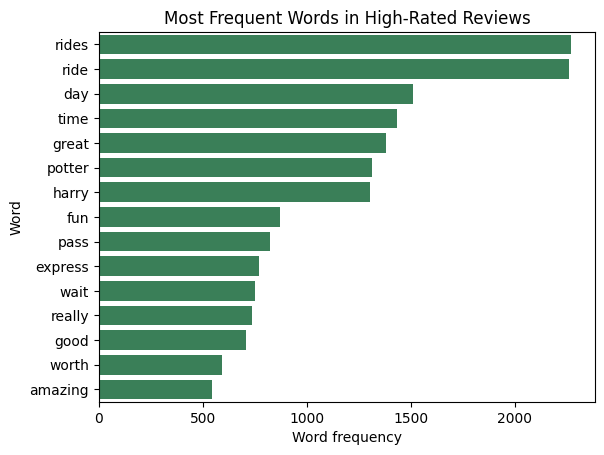

In [25]:
def frequency_frame(group, number_of_words=15):
    counts = Counter(
        word
        for tokens in comparison.loc[
            comparison["rating_group"] == group,
            "tokens"
        ]
        for word in tokens
    )
    return (
        pd.DataFrame(
            counts.most_common(number_of_words),
            columns=["word", "frequency"]
        )
        .sort_values("frequency", ascending=False)
    )


low_frequency = frequency_frame("Low (1–2)")
high_frequency = frequency_frame("High (4–5)")

sns.barplot(
    data=low_frequency,
    x="frequency",
    y="word",
    color="firebrick"
)
plt.title("Most Frequent Words in Low-Rated Reviews")
plt.xlabel("Word frequency")
plt.ylabel("Word")
plt.show()

sns.barplot(
    data=high_frequency,
    x="frequency",
    y="word",
    color="seagreen"
)
plt.title("Most Frequent Words in High-Rated Reviews")
plt.xlabel("Word frequency")
plt.ylabel("Word")
plt.show()

**What do the bar charts make easier to compare than the word clouds?**

Your answer: The bar charts make it easier to compare the exact frequencies and ranking of the most common words.

**Which repeated words appear prominently in both groups?**

Your answer: Words such as "ride," "rides," "day," "time," "harry," "potter," "pass," and "express" appear prominently in both groups.

## 11. Compare review lengths

Use `sns.boxplot()` to compare `review_length_words` across the Low and High rating groups. Use `order=["Low (1–2)", "High (4–5)"]`, choose a human-readable color, and add a descriptive title and axis labels.

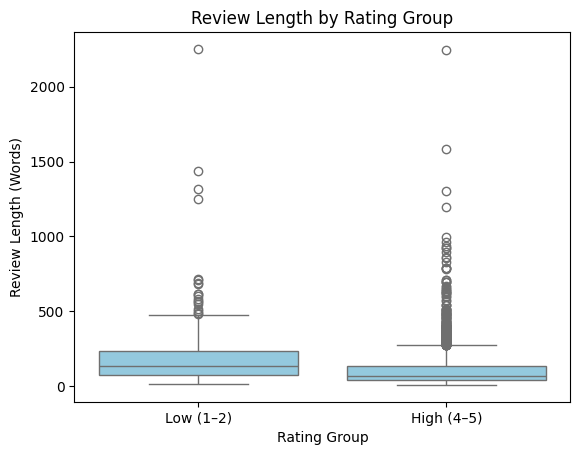

In [26]:
# Write your code here.
sns.boxplot(
    data=comparison,
    x="rating_group",
    y="review_length_words",
    order=["Low (1–2)", "High (4–5)"],
    color="skyblue"
)

plt.title("Review Length by Rating Group")
plt.xlabel("Rating Group")
plt.ylabel("Review Length (Words)")
plt.show()

**How do the centers and variability of review length compare between the groups?**

Your answer: Low-rated reviews tend to be longer and have more variability than high-rated reviews. The median is about 134 words for low-rated reviews compared with 69 words for high-rated reviews.

# Step 6: Conclusion and limitation

**Write a concise conclusion that answers the research question using evidence from the word-frequency and review-length figures.**

Your answer: Low- and high-rated reviews shared common words such as "ride," "rides," "day," and "time," but high-rated reviews also frequently used positive words like "great," "fun," and "amazing." Low-rated reviews were generally longer, with a median of 134 words compared with 69 words for high-rated reviews.

**Why do frequent words not necessarily identify the most important causes of a visitor's rating?**

Your answer: Frequent words show what visitors talked about, but they do not explain why a visitor gave a certain rating or the context in which the words were used.

**How might the historical time span limit conclusions about current Universal Studios Florida experiences?**

Your answer: The reviews are from 2004 to 2021, so they may not reflect current rides, prices, services, or visitor experiences at Universal Studios Florida.

## AI-use reflection

**State whether you used an AI tool and, if you did, identify one suggestion you checked and explain what you accepted, modified, or rejected.**

Your answer: I used AI for clarification when I was unsure about some steps. One suggestion explained why group size matters when comparing word frequencies. I accepted it because it helped me understand that a larger group naturally has more opportunities for words to appear.

## Submission checklist

- Run every code cell from top to bottom.
- Use all requested DataFrame and feature names.
- Complete every written-response cell.
- Give each figure a readable title and axis labels when axes are present.
- Support the conclusion with evidence from the figures and calculated values.
- Explain relevant limitations of the text and sample.
- Keep the notebook organized and readable.
- Submit the completed notebook by the deadline.